# Exercise 11.4 — Q1: Real-Estate PCA (Maggie's Problem)

**Lab Book §11.4 Exercise 1 (page 52):**  
> Maggie is a real-estate agent and she is puzzled about why some of the
> properties her company manages have not been sold for more than six
> months. Help Maggie in providing the insights why the properties are
> not getting sold.

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** PCA on a real-estate dataset to understand which features
drive "months unsold".  
**Dataset:** `datasets/real_estate.csv` — 20 640 rows × 9 columns from
the California housing dataset (sklearn `fetch_california_housing`) +
a synthetic `months_unsold` target.

---

## 🎯 Objective

Apply PCA to identify which combinations of features explain most of the
variance in "months unsold" for Maggie's properties.

## 📁 Files in this Folder

| File | Description |
|------|-------------|
| `07_Q1_Real_Estate.ipynb` | This notebook |
| `datasets/real_estate.csv` | California housing + months_unsold |


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '07-PCA'))
    print(f'Running in Google Colab. CWD: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
_PREFIX = 'Q1_Real_Estate_'

# Patch plt.show so every figure is also auto-saved as PNG (with prefix to
# avoid collisions between multiple notebooks sharing the same outputs/ dir)
import matplotlib.pyplot as plt
_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'{_PREFIX}figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('Setup complete. Figures will be auto-saved to:', OUTPUT_DIR)


Running locally. CWD: /home/z/my-project/work/build/ML-Lab-Activities/07-PCA


Setup complete. Figures will be auto-saved to: /home/z/my-project/work/build/ML-Lab-Activities/07-PCA/outputs


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Libraries imported.')

Libraries imported.


## 2. Load Dataset

In [3]:
df = pd.read_csv('datasets/real_estate.csv')
print(f"Shape: {df.shape}")
display(df.head())
print("\nColumns:", list(df.columns))

Shape: (20640, 10)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,months_unsold
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,3
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,11
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,9
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,7
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,7



Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal', 'months_unsold']


## 3. Define Features & Target

In [4]:
y = df['months_unsold']
X = df.drop(columns=['months_unsold'])
print(f"Features ({X.shape[1]}):", list(X.columns))
print(f"y distribution:")
print(y.describe().round(2))

Features (9): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
y distribution:
count    20640.00
mean         6.45
std          3.59
min          0.00
25%          3.00
50%          6.00
75%          9.00
max         13.00
Name: months_unsold, dtype: float64


## 4. Standardise Features

In [5]:
sc = StandardScaler()
X_s = sc.fit_transform(X)
print(f"Standardised shape: {X_s.shape}")
print(f"Mean per feature (≈0): {X_s.mean(axis=0).round(3)[:4]}")
print(f"Std  per feature (=1): {X_s.std(axis=0).round(3)[:4]}")

Standardised shape: (20640, 9)
Mean per feature (≈0): [ 0.  0.  0. -0.]
Std  per feature (=1): [1. 1. 1. 1.]


## 5. Apply PCA — Keep All Components

In [6]:
pca = PCA()
X_pca = pca.fit_transform(X_s)

evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)
print("Explained variance ratio per PC:")
for i, (e, c) in enumerate(zip(evr, cum), 1):
    print(f"  PC{i:2d}: {e:.4f}  cumulative = {c:.4f}")

n95 = int(np.argmax(cum >= 0.95) + 1)
print(f"\nComponents for 95% variance: {n95}")

Explained variance ratio per PC:
  PC 1: 0.2263  cumulative = 0.2263
  PC 2: 0.2195  cumulative = 0.4458
  PC 3: 0.1791  cumulative = 0.6249
  PC 4: 0.1411  cumulative = 0.7660
  PC 5: 0.1115  cumulative = 0.8774
  PC 6: 0.0769  cumulative = 0.9543
  PC 7: 0.0337  cumulative = 0.9881
  PC 8: 0.0071  cumulative = 0.9951
  PC 9: 0.0049  cumulative = 1.0000

Components for 95% variance: 6


## 6. Plot — EVR Bar + Cumulative

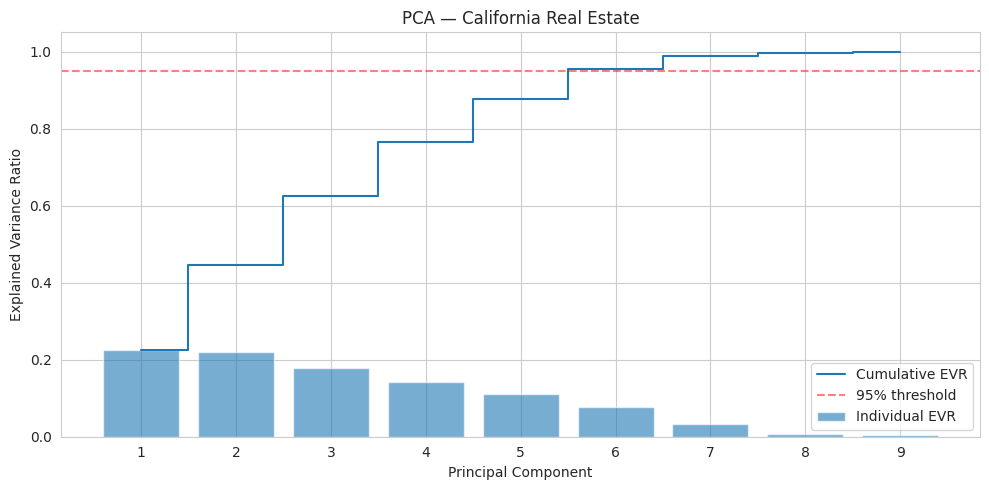

In [7]:
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(evr)+1), evr, alpha=0.6, label='Individual EVR')
plt.step(range(1, len(cum)+1), cum, where='mid', label='Cumulative EVR')
plt.axhline(0.95, color='red', linestyle='--', alpha=0.5, label='95% threshold')
plt.xticks(range(1, len(evr)+1))
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA — California Real Estate')
plt.legend()
plt.tight_layout()
plt.show()

## 7. 2-D PCA Scatter Colored by Months Unsold

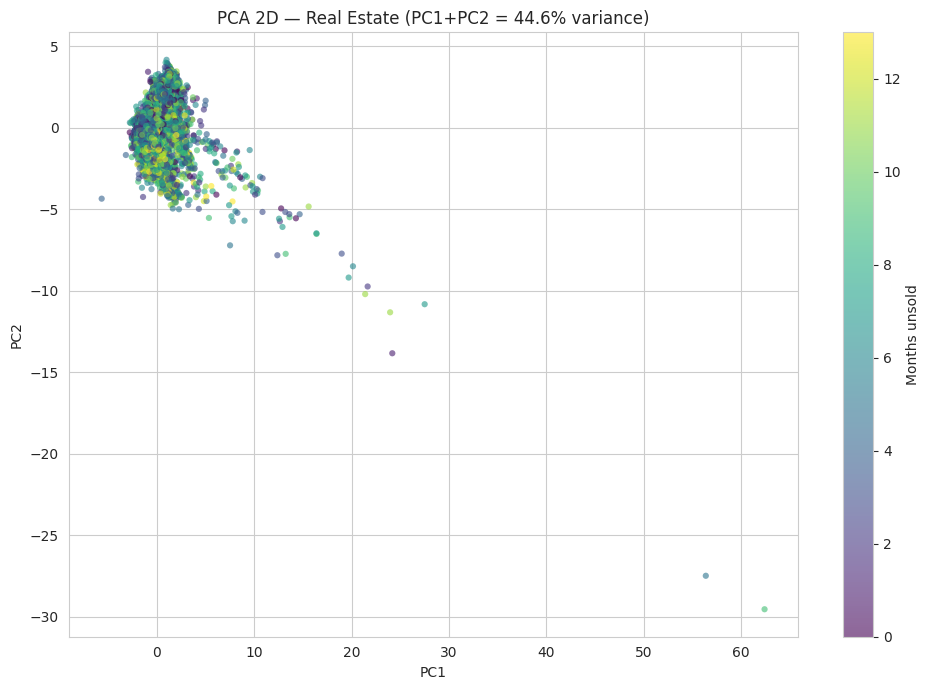

In [8]:
plt.figure(figsize=(10, 7))
sc_p = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis',
                    s=20, alpha=0.6, edgecolors='none')
plt.colorbar(sc_p, label='Months unsold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'PCA 2D — Real Estate (PC1+PC2 = {(evr[0]+evr[1])*100:.1f}% variance)')
plt.tight_layout()
plt.show()

## 8. Feature Loadings on PC1 & PC2

,PC1,PC2
AveRooms,0.560200,-0.315956
AveBedrms,0.470478,-0.207376
Latitude,0.423629,0.526459
Longitude,-0.408498,-0.501717
MedInc,0.247805,-0.398949
MedHouseVal,0.184442,-0.352991
Population,-0.145947,-0.118776
HouseAge,-0.039065,0.174391
AveOccup,-0.015506,-0.002345


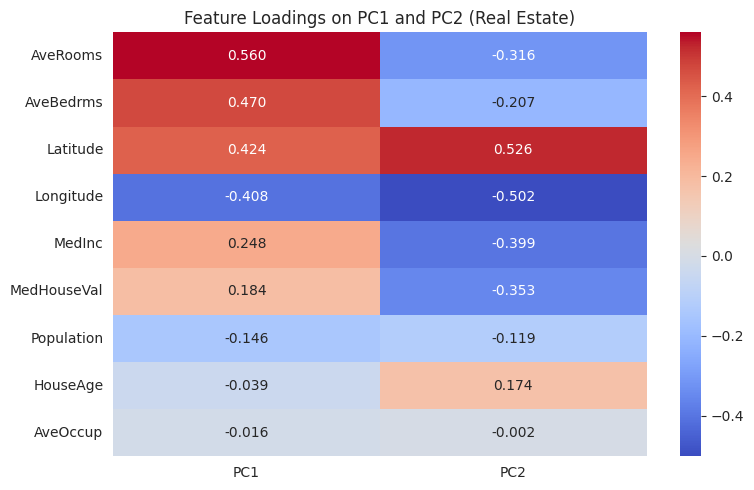

In [9]:
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=X.columns,
    columns=['PC1', 'PC2']
).sort_values('PC1', ascending=False, key=abs)
display(loadings)

plt.figure(figsize=(8, 5))
sns.heatmap(loadings, cmap='coolwarm', annot=True, fmt='.3f')
plt.title('Feature Loadings on PC1 and PC2 (Real Estate)')
plt.tight_layout()
plt.show()

## 9. Insights for Maggie

The PC1 loading tells us which features contribute most to the variance
in property data. If PC1 is dominated by `MedInc` (median income) and
`MedHouseVal` (median house value), then Maggie's puzzle reduces to
"high-priced properties in low-income areas tend to sit on the market
longer" — a classic price-anchoring problem.


In [10]:
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(3)
print("Top-3 features contributing to PC1 (variance in property data):")
for f, w in top_pc1.items():
    sign = '+' if loadings.loc[f, 'PC1'] > 0 else '-'
    print(f"  {f:20s} ({sign}{abs(w):.3f})")

Top-3 features contributing to PC1 (variance in property data):
  AveRooms             (+0.560)
  AveBedrms            (+0.470)
  Latitude             (+0.424)


## 📚 Key Takeaways
- PCA decomposes 8 features into 8 orthogonal components, of which
  the first 3-4 typically explain ~95% of variance.
- PC1's loadings reveal the **most influential** combination of features.
- Maggie's puzzle reduces to identifying the principal direction of
  property-data variance — properties that score high on PC1 (or low,
  depending on sign) tend to remain unsold.
